# Lección 9 - Clasificación con el Vision Transformer pre-entrenado

En esta lección veremos cómo usar un modelo Vision Transformer pre-entrenado para realizar la clasificación de imágenes.

En esencia, la lógica es muy similar a la que vimos en la lección 5 cuando usamos Redes Convolucionales, tan sólo cambia el modelo que usaremos.

Al final, veremos cuándo se sugiere usar este enfoque y cuándo no.

## 1. Librerías a usar

Una de las formas más sencillas de acceder a este modelo pre-entrenado es usando la librería "transformers" de HuggingFace:

In [17]:
!pip install transformers

Y a continuación importamos las librerías a usar:

In [18]:
# Modelo y transformador (HuggingFace)
from transformers import ViTForImageClassification, ViTImageProcessor
import torch

# Visualización
from PIL import Image # versión 11.3.0
import os
import matplotlib.pyplot as plt

## 2. El modelo pre-entrenado

Comencemos cargando el [modelo base pre-entrenado para clasificación](https://huggingface.co/google/vit-base-patch16-224):

In [19]:
RUTA_MODELO = 'google/vit-base-patch16-224'
modelo = ViTForImageClassification.from_pretrained(RUTA_MODELO)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Estas son las principales características del modelo:

- Entrenado con el set ImageNet-21K (14 millones de imágenes y 21.000 categorías)
- Luego ha sido afinado con el set ImageNet-1K que contiene 1.28 M de imágenes y 1.000 diferentes categorías.

Veamos cuántos parámetros tiene este modelo:

In [20]:
def conteo_parametros(model):
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    no_entrenables = sum(p.numel() for p in model.parameters() if not p.requires_grad)

    print(f"Parámetros entrenables:     {entrenables:,}")
    print(f"Parámetros no entrenables:  {no_entrenables:,}")
    print(f"Total parámetros:           {entrenables + no_entrenables:,}")

conteo_parametros(modelo)

Parámetros entrenables:     86,567,656
Parámetros no entrenables:  0
Total parámetros:           86,567,656


¡Se trata de un modelo gigantesco (a pesar de que se trata del modelo base)!

Por ejemplo, recordemos que las Redes Convolucionales usadas en lecciones anteriores tiene entre 5 y 12 millones de parámetros aproximadamente.

Veamos otras características de este modelo:

In [21]:
print(f"Tamaño imágenes de entrada: {modelo.config.image_size}")
print(f"Tamaño recuadros: {modelo.config.patch_size}")
print(f"Número de clases: {modelo.config.num_labels}")
print(f"Ids-categorías: {modelo.config.id2label}")

Tamaño imágenes de entrada: 224
Tamaño recuadros: 16
Número de clases: 1000
Ids-categorías: {0: 'tench, Tinca tinca', 1: 'goldfish, Carassius auratus', 2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', 3: 'tiger shark, Galeocerdo cuvieri', 4: 'hammerhead, hammerhead shark', 5: 'electric ray, crampfish, numbfish, torpedo', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich, Struthio camelus', 10: 'brambling, Fringilla montifringilla', 11: 'goldfinch, Carduelis carduelis', 12: 'house finch, linnet, Carpodacus mexicanus', 13: 'junco, snowbird', 14: 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', 15: 'robin, American robin, Turdus migratorius', 16: 'bulbul', 17: 'jay', 18: 'magpie', 19: 'chickadee', 20: 'water ouzel, dipper', 21: 'kite', 22: 'bald eagle, American eagle, Haliaeetus leucocephalus', 23: 'vulture', 24: 'great grey owl, great gray owl, Strix nebulosa', 25: 'European fire salamander, Salamandra salamandra', 26: 'common newt, Tr

Lo anterior quiere decir que:

- El modelo acepta imágenes de entrada de 224x224
- Cada imagen es subdividida en recuadros de 16x16
- Y el modelo puede clasificar la imagen en una de 1.000 posibles categorías

En un momento veremos cómo usar el módulo "ViTImageProcessor" para realizar el pre-procesamiento de las imágenes.

## 2. El set de datos y el pre-procesamiento

Recordemos (lección 5) que para poder usar un modelo pre-entrenado (sin afinación) debemos garantizar que las imágenes a usar tendrán características similares a las usadas durante el entrenamiento del modelo.

Así que usaremos las mismas imágenes de la lección 5:

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Descompresión del archivo ZIP especificado por el usuario

A continuación, se descomprimirá el archivo ZIP proporcionado por el usuario en el directorio `/content/drive`.

In [32]:
import os

ZIP_FILE_PATH = "/content/drive/MyDrive/MAESTRIA VIRTUAL CIENCIA DE DATOS/MAESTRIA_DEEP_LEARNING/LABORATORIOS/NOTEBOOK_5_TRANSFORMERS/LLM_BASICO_VISION_TRANSFORMER/leccion_5 (1).zip"
DESTINATION_PATH = "/content/imagenes" # Change destination to the new 'imagenes' folder

# Create the directory if it doesn't exist
os.makedirs(DESTINATION_PATH, exist_ok=True)

# Descomprimir el archivo
!unzip -q "{ZIP_FILE_PATH}" -d "{DESTINATION_PATH}"

print(f"Archivo '{ZIP_FILE_PATH}' descomprimido en '{DESTINATION_PATH}'")

Archivo '/content/drive/MyDrive/MAESTRIA VIRTUAL CIENCIA DE DATOS/MAESTRIA_DEEP_LEARNING/LABORATORIOS/NOTEBOOK_5_TRANSFORMERS/LLM_BASICO_VISION_TRANSFORMER/leccion_5 (1).zip' descomprimido en '/content/imagenes'


Usemos PIL para leer y mostrar estas imágenes junto con sus tamaños:

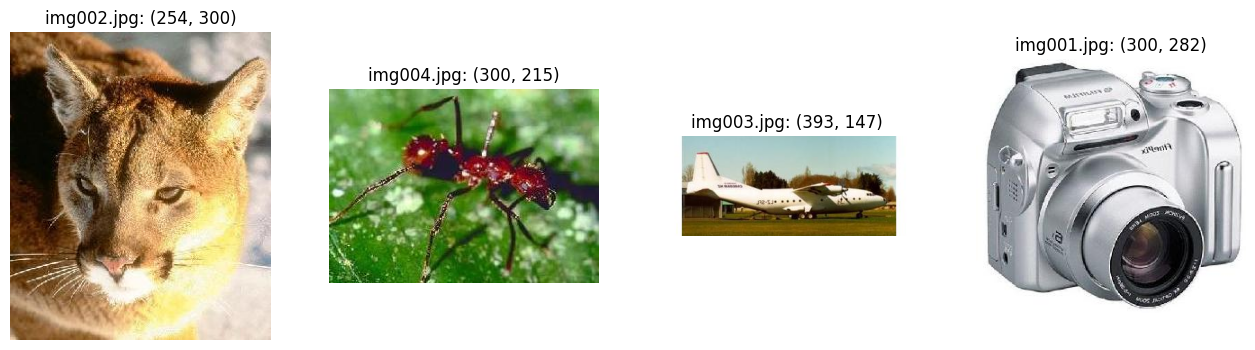

In [33]:
# Leer y mostrar imágenes y sus tamaños
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, ruta_img in zip(axs, os.listdir("/content/imagenes")):
    img = Image.open(os.path.join("/content/imagenes", ruta_img))
    ax.set_title(f"{ruta_img}: {img.size}")
    ax.imshow(img)
    ax.axis('off');

In [34]:
import os
from PIL import Image

# Get one image to demonstrate
image_files = os.listdir("/content/imagenes")
if image_files:
    # Use the first image found
    first_image_path = os.path.join("/content/imagenes", image_files[0])
    img = Image.open(first_image_path)
    print(img.getextrema())
else:
    print("No images found in /content/imagenes.")

((0, 255), (0, 255), (0, 253))


Todas las imágenes son RGB y todas tienen diferentes tamaños. Así que precisamente tendremos que usar "ViTImageProcessor" para realizar su pre-procesamiento antes de llevarlas al Vision Transformer.

## 3. Pre-procesamiento de las imágenes

Veamos entonces cómo usar "VitImageProcessor" para realizar las transformaciones.

Comencemos creando una instancia de este preprocesador:

In [35]:
procesador = ViTImageProcessor.from_pretrained(RUTA_MODELO)

⚠️ A tener en cuenta: la ruta usada debe ser la misma del modelo importado anteriormente ("google/vit-base-patch16-224") ⚠️

Veamos el tipo de transformaciones que realizará este preprocesador sobre las imágenes:

In [36]:
print(procesador)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



¡Y vemos que son muy similares a las que hicimos al momento de usar una Red Convolucional pre-entrenada!

El pre-procesamiento de una imagen es muy sencillo: simplemente cargamos la imagen y se la presentamos como argumento al pre-procesador, usando además el parámetro "return_tensors='pt'":

In [37]:
# Leer la imagen
image = Image.open('/content/imagenes/img003.jpg')

# Imprimir información de la imagen original
print("Imagen original: ")
print(f"\tTamaño: {image.size}")
print(f"\tCanales: {image.getbands()}")
print(f"\tRango de valores: {image.getextrema()}")

# Transformar imagen
inputs = procesador(images=image, return_tensors="pt")

# Imprimir información del tensor resultante
print("Tensor resultante (imagen preprocesada): ")
print(f"\tTamaño: {inputs['pixel_values'].shape}")
print(f"\tTipo: {inputs['pixel_values'].dtype}")
print(f"\tRango de valores: {inputs['pixel_values'].min()}, {inputs['pixel_values'].max()}")
#

Imagen original: 
	Tamaño: (393, 147)
	Canales: ('R', 'G', 'B')
	Rango de valores: ((0, 255), (0, 255), (0, 255))
Tensor resultante (imagen preprocesada): 
	Tamaño: torch.Size([1, 3, 224, 224])
	Tipo: torch.float32
	Rango de valores: -1.0, 1.0


Perfecto. Ya estamos listos para clasificar la imagen usando el Vision Transformer pre-entrenado.

## 4. Clasificación con el ViT pre-entrenado

La predicción implica estos pasos:

1. Mover el modelo pre-entrenado al dispositivo y ponerlo en modo inferencia
2. Inferencia: predecir los logits
3. Post-procesar el resultado de la inferencia para obtener la categoría de la imagen

Veamos cada uno de estos pasos en detalle:

In [38]:
# Mover modelo al dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")
modelo = modelo.to(device)

# Y ponerlo en modo inferencia
modelo.eval()

Usando dispositivo: cpu


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [39]:
# Inferencia en espacio logits
with torch.no_grad():
    outputs = modelo(**inputs)

logits = outputs.logits
print(logits)
print(logits.shape)

tensor([[ 4.6545e-01,  2.3307e-01,  3.7106e-01,  6.4102e-01,  9.1513e-01,
          7.1592e-01,  6.5844e-01, -1.1121e+00, -2.5455e-01, -8.2877e-01,
          5.7961e-01, -1.7131e+00, -6.2889e-01, -9.1283e-02, -7.6857e-01,
          5.2639e-01, -3.4968e-01, -1.1569e+00, -3.0470e-01, -2.9363e-01,
          2.5713e-01,  6.8252e-01, -1.6429e-01, -5.7856e-02, -9.0948e-02,
         -2.0707e-01, -6.4185e-01, -1.4762e-01, -3.3291e-01,  6.6492e-01,
          1.6019e-01, -1.7233e-01, -2.1837e-01,  7.7330e-01,  6.0196e-01,
          3.1113e-01,  6.8027e-01,  4.0750e-01, -6.4958e-01, -9.3296e-01,
         -1.4048e+00, -2.7491e-01, -8.4811e-01, -5.6166e-01, -6.0343e-01,
         -1.7588e-01, -3.0005e-01, -7.1842e-01, -5.5976e-01, -7.4842e-01,
         -8.7140e-01,  6.4442e-01,  2.7137e-01, -1.1950e-01, -1.9967e-01,
         -6.2571e-01, -9.8768e-01, -3.8811e-01,  1.2381e-02, -3.1051e-01,
         -1.7909e-01, -7.0763e-01,  4.3398e-01,  3.8751e-02, -1.6253e-01,
          2.2388e-01, -4.2020e-01,  2.

In [40]:
# Etiqueta predicha y categoría correspondiente
id_pred = logits.argmax(dim=-1).item()
cat_pred = modelo.config.id2label[id_pred]

print(f"Etiqueta predicha: {id_pred}")
print(f"Categoría predicha: {cat_pred}")

Etiqueta predicha: 404
Categoría predicha: airliner


Y para facilitar las cosas podemos poner todo esto en una función similar a la usada en la lección 5, donde se predicen las top-5 categorías:

In [41]:
def clasificar_imagen(ruta_img, model, processor, device):
    # Leer imagen, forzar conversión a RGB y pre-procesar
    img = Image.open(ruta_img).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    # Inferencia
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs) # batch_size x 1000

    # Obtener top-5 predicciones
    probs = torch.nn.functional.softmax(outputs['logits'][0], dim=0)
    top5_probs, top5_idxs = probs.topk(5)

    # Categoría final
    pos_cat_final = outputs['logits'][0].argmax()
    y_pred = model.config.id2label[pos_cat_final.item()]

    # Imprimir top-5 predicciones y categoría final
    print(f"\nImagen: {ruta_img}")
    for p, idx in zip(top5_probs, top5_idxs):
        print(f"  {p.item():.4f}  -  {model.config.id2label[idx.item()]}")
    print(f"  **Categoría predicha: {y_pred}**")

    # Mostrar imagen
    plt.imshow(img)
    plt.axis('off');

Y veamos cómo funciona este clasificador para nuestras imágenes de prueba:


Imagen: imagenes/img004.jpg
  0.9970  -  ant, emmet, pismire
  0.0004  -  tiger beetle
  0.0004  -  ground beetle, carabid beetle
  0.0003  -  lacewing, lacewing fly
  0.0002  -  walking stick, walkingstick, stick insect
  **Categoría predicha: ant, emmet, pismire**


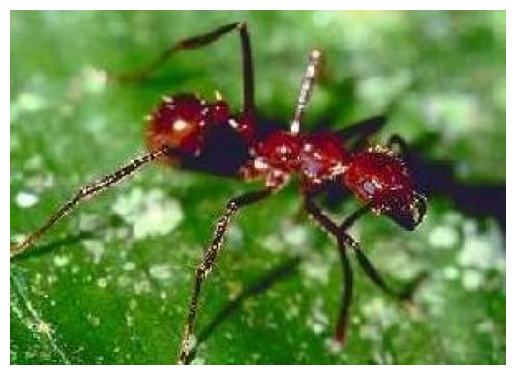

In [42]:
ruta_img = 'imagenes/img004.jpg'
clasificar_imagen(ruta_img, modelo, procesador, device)

Lo hace muy bien. De hecho, la imagen 4 es clasificada correctamente en este caso (lo cual no ocurrió con el modelo usado en la lección 5).

## 5. ¿Cuándo usar y cuándo no usar este enfoque?

- ✅ Cuando las imágenes que queremos clasificar **tienen características similares** a las del set de entrenamiento del modelo pre-entrenado (lo cual ocurre en este caso)
- ✅ Cuando tenemos memoria RAM y capacidad de procesamiento suficientes (pues el modelo ViT requiere mayor capacidad de cómputo y almacenamiento que una Red Convolucional)
- ❌ Cuando las imágenes que queremos clasificar tienen **características muy diferentes** a las del set de entrenamiento del modelo pre-entrenado.

## 6. Ventajas y desventajas de este enfoque

- 👍 Fácil de implementar
- 👍 No se requiere un set de entrenamiento
- 👎 Puede ser difícil encontrar un modelo pre-entrenado adecuado para nuestras imágenes